<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/Copy_of_hypothesis_testing_and_p_hacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

In [ ]:
#resize charts to fit screen if using Jupyter Notebook
plt.rcParams['figure.figsize']=[15,5]
#plt.xkcd()

# Load dataset
data terdiri dari data harga penutupan saham harian mentah dari tahun 1986 hingga 2018

In [ ]:
#Daily S&P500 data from 1986==>
url = "https://raw.githubusercontent.com/Patrick-David/Stocks_Significance_PHacking/master/spx.csv"
df = pd.read_csv(url,index_col='date', parse_dates=True)

#view raw S&P500 data
df

,close
date,
1986-01-02,209.59
1986-01-03,210.88
1986-01-06,210.65
1986-01-07,213.80
1986-01-08,207.97
...,...
2018-06-25,2717.07
2018-06-26,2723.06
2018-06-27,2699.63


# mengubah data harga harian menjadi persentase perubahan harian

In [ ]:
#To model returns we will use daily % change
daily_ret = df['close'].pct_change()
#drop the 1st value - nan
daily_ret.dropna(inplace=True)
#daily %change
daily_ret.head()

date
1986-01-03    0.006155
1986-01-06   -0.001091
1986-01-07    0.014954
1986-01-08   -0.027268
1986-01-09   -0.008944
Name: close, dtype: float64

# Hitung Annualized monthly volatility
Annualized monthly volatility is a measure of the amount of variation or fluctuations in the monthly returns of an investment, scaled to an annual basis. It is a common measure used in finance to quantify the risk associated with an investment over a one-year period.

For example, if an investment has a monthly volatility of 2%, then its annualized monthly volatility would be 2% x √12 = 6.57%. This means that, on average, the investment's returns are expected to vary by 6.57% per year.

date
1986-01-31    0.033317
1986-02-28    0.023585
1986-03-31    0.027961
1986-04-30    0.037426
1986-05-31    0.027412
Freq: M, Name: close, dtype: float64


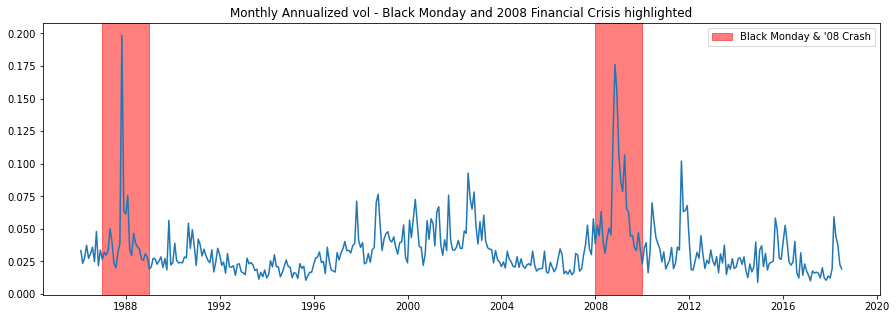

In [ ]:
#use pandas to resample returns per month and take Standard Dev as measure of Volatility
#then annualize by multiplying by sqrt of number of periods (12)
mnthly_annu = daily_ret.resample('M').std()* np.sqrt(12)

print(mnthly_annu.head())
#we can see major market events show up in the volatility
plt.plot(mnthly_annu)
plt.axvspan('1987','1989',color='r',alpha=.5)
plt.axvspan('2008','2010',color='r',alpha=.5)
plt.title('Monthly Annualized vol - Black Monday and 2008 Financial Crisis highlighted')
labs = mpatches.Patch(color='red',alpha=.5, label="Black Monday & '08 Crash")
plt.legend(handles=[labs])

In [ ]:
mnthly_annu[:12]

date
1986-01-31    0.033317
1986-02-28    0.023585
1986-03-31    0.027961
1986-04-30    0.037426
1986-05-31    0.027412
1986-06-30    0.030849
1986-07-31    0.035907
1986-08-31    0.024875
1986-09-30    0.048035
1986-10-31    0.021720
1986-11-30    0.033716
1986-12-31    0.026474
Freq: M, Name: close, dtype: float64

In [ ]:
ranked[:24]

1986-01-31     5.0
1986-02-28     9.0
1986-03-31    12.0
1986-04-30    11.0
1986-05-31     6.0
1986-06-30     1.0
1986-07-31     3.0
1986-08-31     2.0
1986-09-30    10.0
1986-10-31     4.0
1986-11-30     8.0
1986-12-31     7.0
1987-01-31     7.0
1987-02-28    10.0
1987-03-31    11.0
1987-04-30     6.0
1987-05-31    12.0
1987-06-30     8.0
1987-07-31     9.0
1987-08-31     5.0
1987-09-30     1.0
1987-10-31     4.0
1987-11-30     2.0
1987-12-31     3.0
Freq: M, Name: close, dtype: float64

In [ ]:
#for each year rank each month based on volatility lowest=1 Highest=12
ranked = mnthly_annu.groupby(mnthly_annu.index.year).rank() #dalam tiap tahun dihitung rankingnya per bulan
#ranked[:12]
#average the ranks over all years for each month
final = ranked.groupby(ranked.index.month).mean() #tiap bulan dihitung rata2nya dari semua tahun
final

1     6.093750
2     6.343750
3     6.343750
4     6.218750
5     7.250000
6     6.322581
7     6.709677
8     6.709677
9     5.838710
10    6.967742
11    5.806452
12    6.838710
Name: close, dtype: float64

# visualisasi peringkat volatilitas per bulan dari 1986-2018

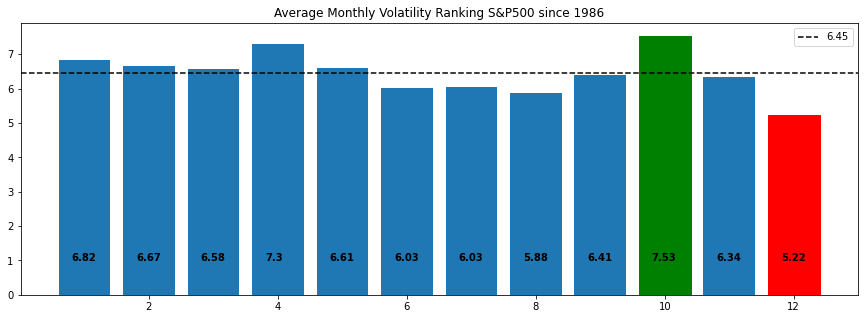

In [ ]:
#plot results for ranked s&p 500 volatility
#clearly October has the highest AMVR
#and December has the lowest
#mean of 6.45 is plotted

b_plot = plt.bar(x=final.index,height=final)
b_plot[9].set_color('g')
b_plot[11].set_color('r')
for i,v in enumerate(round(final,2)):
    plt.text(i+.8,1,str(v), color='black', fontweight='bold')
plt.axhline(final.mean(),ls='--',color='k',label=round(final.mean(),2))
plt.title('Average Monthly Volatility Ranking S&P500 since 1986')

plt.legend()
plt.show()


# untuk melihat bulan apa yg memiliki peringkat volatilitas paling ekstrim (menghitung deviasi absolut)

In [ ]:
#take abs value move from the mean
#we see Dec and Oct are the biggest abs moves

fin = abs(final - final.mean())
print(fin.sort_values())
Oct_value = fin[10]
Dec_value = fin[12]
print('Extreme Dec value:', Dec_value)
print('Extreme Oct value:', Oct_value)

date
9     0.044271
11    0.106771
3     0.125237
5     0.155540
2     0.216146
1     0.367661
7     0.419271
6     0.420218
8     0.575521
4     0.852509
10    1.080729
12    1.231771
Name: close, dtype: float64
Extreme Dec value: 1.231770833333333
Extreme Oct value: 1.080729166666667


# Hypothesis testing


*   H0: tidak ada perbedaan antar tiap bulan
*   H1: ada perbedaan di tiap bulannya


Hipotesis null mengasumsikan bahwa segala jenis perbedaan antara bulan pada kumpulan data disebabkan oleh kebetulan. sehingga label date disini akan diabaikan

In [ ]:
#as our Null is that no seasonality exists or alternatively that the month does not matter in terms of AMVR,
#we can shuffle 'date' labels
#for simplicity, we will shuffle the 'daily' return data, which has the same effect as shuffling 'month' labels

#generate null data

new_df_sim = pd.DataFrame()
highest_only = []

count=0
n=1000
for i in range(n):
    #sample same size as dataset, drop timestamp
    daily_ret_shuffle = daily_ret.sample(8191).reset_index(drop=True)
    #add new timestamp to shuffled data
    daily_ret_shuffle.index = (pd.bdate_range(start='1986-1-3',periods=8191))

    #then follow same data wrangling as before...
    mnthly_annu = daily_ret_shuffle.resample('M').std()* np.sqrt(12)

    ranked = mnthly_annu.groupby(mnthly_annu.index.year).rank()
    sim_final = ranked.groupby(ranked.index.month).mean()
    #add each of 1000 sims into df
    new_df_sim = pd.concat([new_df_sim,sim_final],axis=1)

    #also record just highest AMVR for each year (we will use this later for p-hacking explanation)
    maxi_month = max(sim_final)
    highest_only.append(maxi_month)

#calculate absolute deviation in AMVR from the mean
all_months = new_df_sim.values.flatten()
mu_all_months = all_months.mean()
abs_all_months = abs(all_months-mu_all_months)    

#calculate absolute deviation in highest only AMVR from the mean
mu_highest = np.mean(highest_only)
abs_highest = [abs(x - mu_all_months) for x in highest_only]

In [ ]:
abs_all_months[:5] #12000

array([1.17313676, 0.76688676, 0.17061324, 0.29813676, 0.73311324])

In [ ]:
new_df_sim

,close,close,close,close,close,close,close,close,close,close
1,6.218750,6.375000,7.656250,6.656250,5.531250,5.500000,6.343750,6.781250,6.375000,5.843750
2,6.312500,6.312500,6.843750,6.500000,5.687500,6.593750,6.125000,5.843750,7.062500,7.500000
3,7.593750,6.687500,6.250000,6.531250,7.125000,6.593750,6.906250,7.468750,6.343750,6.406250
4,5.468750,5.937500,5.718750,6.281250,5.281250,5.625000,6.218750,5.093750,6.437500,6.500000
5,7.125000,5.625000,6.343750,7.125000,6.875000,6.968750,6.500000,6.375000,7.125000,7.593750
6,5.806452,7.838710,7.096774,6.967742,7.064516,6.258065,6.580645,6.419355,6.645161,6.000000
7,6.838710,5.709677,6.483871,5.612903,6.032258,7.096774,6.903226,6.870968,5.870968,6.419355
8,6.774194,7.032258,6.032258,6.903226,6.387097,6.935484,6.290323,6.516129,7.645161,6.645161
9,6.032258,6.225806,6.000000,6.483871,6.580645,5.967742,5.774194,6.741935,6.129032,4.935484
10,5.387097,8.193548,6.870968,6.354839,6.967742,6.548387,6.387097,6.161290,6.096774,6.838710


In [ ]:
highest_only #1000

[7.59375,
 8.193548387096774,
 7.65625,
 7.125,
 7.258064516129032,
 7.387096774193548,
 6.90625,
 7.483870967741935,
 7.645161290322581,
 7.59375]

# P value yg didapat dari semua bulan (all_months)
saat digunakan all_months, hal ini untuk menjawab pertanyaan "Seberapa besar kemungkinan bulan Desember akan tampak ekstrim ini secara kebetulan?”

kalau p value nya <5% artinya ada sedikit bulan (<5%) yg memiliki peringkat volatilitas lebih besar dari desember. sehingga desember memililki volatilitas tinggi bukan karena kebetulan.

In [ ]:
Dec_value #volatilitas

1.231770833333333

In [ ]:
#count number of months in sim data where ave-vol-rank is >= Dec
#Note: we are using Dec not Oct, as Dec has highest absolute deviation from the mean
#hasilnya signifikan karena hanya 
count=0
for i in abs_all_months:
    if i> Dec_value:
        count+=1
ans = count/len(abs_all_months)        
print('p-value:', ans )

p-value: 0.0455


# P value yg didapat dari maksimum AMVR per tahunnya (highest_only)
saat digunakan highest_only, digunakan untuk menjawab “Seberapa besar kemungkinan bulan apa pun akan tampak ekstrim ini secara kebetulan?”

karena p value nya >5% artinya tidak signifikan, terlalu banyak bulan (apapun) yg memiliki peringkat volatilitas lebih besar dari desember. --> gagal tolak H0: tidak ada perbedaan antar tiap bulan



In [ ]:
#same again but just considering highest AMVR for each of 100 trials
count=0
for i in abs_highest:
    if i> Dec_value:
        count+=1
ans = count/len(abs_highest)        
print('p-value:', ans )

p-value: 0.239


In [ ]:
abs_all_months_95 = np.quantile(abs_all_months,.95)
abs_all_months_95
#abs_highest_95 = np.quantile(abs_highest,.95)
#abs_highest_95

1.2044906754032256

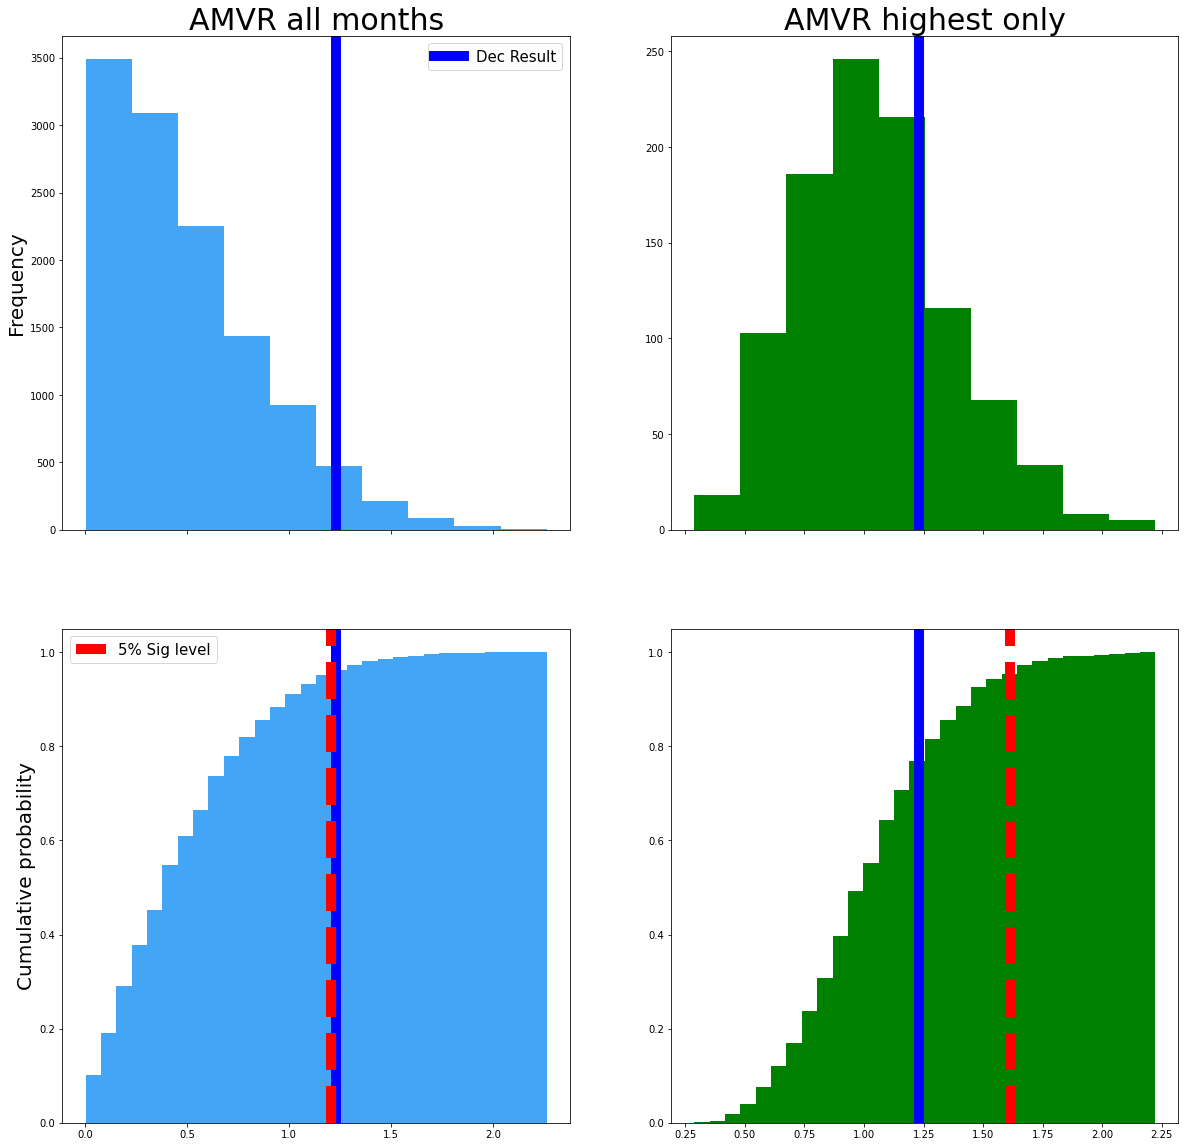

In [ ]:
abs_all_months_95 = np.quantile(abs_all_months,.95)
abs_highest_95 = np.quantile(abs_highest,.95)

fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,sharex='col',figsize=(20,20))

#plot 1
ax1.hist(abs_all_months,histtype='bar',color='#42a5f5')
ax1.set_title('AMVR all months',fontsize=30)
ax1.set_ylabel('Frequency',fontsize=20)
ax3.hist(abs_all_months,density=1,histtype='bar',cumulative=True,bins=30,color='#42a5f5')
ax3.set_ylabel('Cumulative probability',fontsize=20)
ax1.axvline(Dec_value,color='b',label='Dec Result',lw=10)
ax3.axvline(Dec_value,color='b',lw=10)
ax3.axvline(abs_all_months_95,color='r',ls='--',label='5% Sig level',lw=10)

#plot2
ax2.hist(abs_highest,histtype='bar',color='g')
ax2.set_title('AMVR highest only',fontsize=30)
ax2.axvline(Dec_value,color='b',lw=10)
ax4.hist(abs_highest,density=1,histtype='bar',cumulative=True,bins=30,color='g')
ax4.axvline(Dec_value,color='b',lw=10)
ax4.axvline(abs_highest_95,color='r',ls='--',lw=10)

ax1.legend(fontsize=15)
ax3.legend(fontsize=15)

Berdasarkan hasil di gambar kolom 2, hasil pengujian hypothesis tidak signifikan. begitu pula dengan p value yg dihasilkan > 5%. sehingga gagal tolak H0. 

*   H0: tidak ada musiman atau bulan tidak menjadi masalah/ tidak mempengaruhi dalam hal AMVR

**pentingnya mengenali dan mengoreksi bias perbandingan berganda dan menghindari jebakan p-hacking** dan menunjukkan bagaimana hasil yang tampaknya signifikan bisa menjadi tidak signifikan.

tadi kita menentukan nilai extreme Dec_value, dari max(monthly volatility dari semua bulan). oleh karena itu dibandingkan highest only amvr dari semua bulan, tidak menggunakan all_month
